# SqueezeNet Platform Comparison & Result Export

This notebook runs the comprehensive SqueezeNet benchmark (using the existing `SqueezeNetBenchmarker` class) and saves results in **both JSON and CSV** formats matching the structure in previously generated files:

- `squeezenet_results_<timestamp>.json`
- `squeezenet_summary_<timestamp>.csv`

You can adjust the number of runs or enable quantization below. The format is intentionally kept identical to the standalone script for consistency across automated + interactive workflows.

In [21]:
# Imports & utilities
import os, json, platform, psutil, sys, time
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from tqdm import tqdm

# Reuse (light) version of SqueezeNetBenchmarker if script not imported
try:
    from squeezenet_benchmark import SqueezeNetBenchmarker
except ImportError:
    class SqueezeNetBenchmarker:
        def __init__(self, use_quantized=False):
            self.model=None; self.device=None; self.test_input=None; self.model_size_mb=0; self.use_quantized=use_quantized
        def setup(self):
            if torch.backends.mps.is_available(): self.device=torch.device('mps')
            elif torch.cuda.is_available(): self.device=torch.device('cuda')
            else: self.device=torch.device('cpu')
            self.model = models.squeezenet1_1(pretrained=True).eval().to(self.device)
            if self.use_quantized:
                self.model = torch.quantization.quantize_dynamic(self.model,{torch.nn.Linear, torch.nn.Conv2d},dtype=torch.qint8)
            self.model_size_mb = sum(p.nelement()*p.element_size() for p in self.model.parameters())/(1024*1024)
            self.test_input = torch.randn(1,3,224,224).to(self.device)
        def benchmark_core_performance(self, num_runs=50, warmup_runs=10):
            for _ in range(warmup_runs):
                with torch.no_grad(): _ = self.model(self.test_input)
            if self.device.type in ['cuda','mps'] and self.device.type=='cuda': torch.cuda.synchronize()
            times=[]; cpu=[]; mem=[]; gpu=[]; proc=psutil.Process()
            for _ in tqdm(range(num_runs), desc='Benchmarking'):
                start=time.perf_counter();
                with torch.no_grad(): _=self.model(self.test_input)
                if self.device.type=='cuda': torch.cuda.synchronize()
                end=time.perf_counter()
                times.append((end-start)*1000)
                cpu.append(proc.cpu_percent())
                mem.append(proc.memory_info().rss/(1024*1024))
                gpu.append(torch.cuda.memory_allocated()/(1024*1024) if self.device.type=='cuda' else 0)
            import numpy as np
            return {'inference_times':times,'cpu_usage':cpu,'memory_usage':mem,'gpu_memory_usage':gpu,'statistics':{
                'mean_inference_time':float(np.mean(times)), 'std_inference_time':float(np.std(times)),
                'min_inference_time':float(np.min(times)),'max_inference_time':float(np.max(times)),
                'p95_inference_time':float(np.percentile(times,95)),'p99_inference_time':float(np.percentile(times,99)),
                'mean_memory_usage':float(np.mean(mem)),'peak_memory_usage':float(np.max(mem)),
                'mean_cpu_usage':float(np.mean(cpu)),'peak_cpu_usage':float(np.max(cpu)),
                'mean_gpu_memory':float(np.mean(gpu)),'peak_gpu_memory':float(np.max(gpu))}}
        def benchmark_latency_scenarios(self, network_delays=[0,50,500]):
            results={}
            for d in network_delays:
                inf=[]; tot=[]; over=[]
                for _ in range(10):
                    t0=time.perf_counter(); time.sleep(d/1000.0)
                    s=time.perf_counter();
                    with torch.no_grad(): _=self.model(self.test_input)
                    if self.device.type=='cuda': torch.cuda.synchronize()
                    e=time.perf_counter(); time.sleep(d/1000.0); t1=time.perf_counter()
                    inf.append((e-s)*1000); tot.append((t1-t0)*1000); over.append((t1-t0 - (e-s))*1000)
                inf=np.array(inf); tot=np.array(tot); over=np.array(over)
                results[d]={'mean_inference':float(np.mean(inf)),'mean_total':float(np.mean(tot)),'mean_network_overhead':float(np.mean(over)),'efficiency_ratio':float(np.mean(inf)/np.mean(tot)*100)}
            return results
        def benchmark_batch_processing(self, batch_sizes=[1,5,10]):
            out={}
            for bs in batch_sizes:
                times=[]; mems=[]; proc=psutil.Process(); batch=torch.randn(bs,3,224,224).to(self.device)
                for _ in range(5):
                    st=time.perf_counter(); m0=proc.memory_info().rss/(1024*1024)
                    with torch.no_grad(): _=self.model(batch)
                    if self.device.type=='cuda': torch.cuda.synchronize()
                    en=time.perf_counter(); m1=proc.memory_info().rss/(1024*1024)
                    times.append((en-st)*1000); mems.append(m1)
                import numpy as np
                avg=float(np.mean(times)); out[bs]={'total_time':avg,'time_per_image':avg/bs,'throughput':bs/(avg/1000),'memory_usage':float(np.mean(mems))}
            return out
        def benchmark_cold_warm_start(self, num_trials=5):
            cold=[]; warm=[]
            for _ in range(num_trials):
                mdl=models.squeezenet1_1(pretrained=True).eval().to(self.device)
                st=time.perf_counter();
                with torch.no_grad(): _=mdl(self.test_input)
                if self.device.type=='cuda': torch.cuda.synchronize();
                cold.append((time.perf_counter()-st)*1000)
                st=time.perf_counter();
                with torch.no_grad(): _=mdl(self.test_input)
                if self.device.type=='cuda': torch.cuda.synchronize();
                warm.append((time.perf_counter()-st)*1000)
            import numpy as np
            return {'cold_starts':cold,'warm_starts':warm,'statistics':{
                'cold_start_mean':float(np.mean(cold)),'cold_start_std':float(np.std(cold)),
                'warm_start_mean':float(np.mean(warm)),'warm_start_std':float(np.std(warm)),
                'startup_overhead':float(np.mean(cold)-np.mean(warm))}}
        def run_comprehensive_benchmark(self, num_runs=50):
            res={'timestamp':datetime.now().isoformat(),'device_info':{'system':platform.system(),'release':platform.release(),'machine':platform.machine(),'processor':platform.processor(),'cpu_cores':psutil.cpu_count(),'total_ram_gb':psutil.virtual_memory().total/(1024**3),'python_version':sys.version,'pytorch_version':torch.__version__,'device_type':str(self.device)},'model_info':{'name':'SqueezeNet','type':'Lightweight CNN','size_mb':self.model_size_mb,'input_shape':[1,3,224,224],'output_shape':[1,1000],'quantized':self.use_quantized,'device':str(self.device)}}
            res['core_performance']=self.benchmark_core_performance(num_runs)
            res['latency_analysis']=self.benchmark_latency_scenarios()
            res['batch_processing']=self.benchmark_batch_processing()
            res['cold_warm_analysis']=self.benchmark_cold_warm_start()
            return res
        def save_results(self, results, output_dir='results'):
            p=Path(output_dir); p.mkdir(exist_ok=True)
            ts=datetime.now().strftime('%Y%m%d_%H%M%S')
            json_file=p/f'squeezenet_results_{ts}.json'
            with open(json_file,'w') as f: json.dump(results,f,indent=2)
            core=results['core_performance']['statistics']; cw=results['cold_warm_analysis']['statistics']
            summary={ 'Model':['SqueezeNet'], 'Device_Tier':['Laptop (Tier 2)'], 'Device_Type':[results['model_info']['device']], 'Model_Size_MB':[results['model_info']['size_mb']], 'Quantized':[results['model_info']['quantized']], 'Mean_Inference_Time_ms':[core['mean_inference_time']], 'Std_Inference_Time_ms':[core['std_inference_time']], 'P95_Inference_Time_ms':[core['p95_inference_time']], 'Mean_Memory_Usage_MB':[core['mean_memory_usage']], 'Peak_Memory_Usage_MB':[core['peak_memory_usage']], 'Mean_CPU_Usage_Percent':[core['mean_cpu_usage']], 'GPU_Memory_MB':[core.get('peak_gpu_memory',0)], 'Cold_Start_Overhead_ms':[cw['startup_overhead']], 'Max_Throughput_imgs_per_sec':[max([results['batch_processing'][bs]['throughput'] for bs in results['batch_processing']])], 'Efficiency_No_Network_Percent':[results['latency_analysis'][0]['efficiency_ratio']], 'Efficiency_500ms_Network_Percent':[results['latency_analysis'][500]['efficiency_ratio']] }
            df=pd.DataFrame(summary); csv_file=p/f'squeezenet_summary_{ts}.csv'; df.to_csv(csv_file,index=False)
            return json_file, csv_file

In [22]:
# Configuration
NUM_RUNS = 100  # adjust for speed vs statistical stability
USE_QUANTIZED = False  # set True to test quantized dynamic version
OUTPUT_DIR = 'results'  # relative to this notebook directory

print(f'Configured: runs={NUM_RUNS}, quantized={USE_QUANTIZED}, output_dir={OUTPUT_DIR}')

Configured: runs=100, quantized=False, output_dir=results


In [23]:
# Run benchmark & save results
bench = SqueezeNetBenchmarker(use_quantized=USE_QUANTIZED)
bench.setup()
results = bench.run_comprehensive_benchmark(NUM_RUNS)
json_path, csv_path = bench.save_results(results, OUTPUT_DIR)
print('Saved files:')
print(json_path)
print(csv_path)

Setting up SqueezeNet benchmarker...
✓ Using CPU
Loading SqueezeNet model...
✓ Model loaded: 4.71 MB
✓ Input shape: [1, 3, 224, 224]
✓ Quantized: False
✓ Device: cpu
=== Starting Comprehensive SqueezeNet Benchmark ===
Running core performance benchmark (10 warmup + 100 runs)...


/Users/belix/Documents/edgeai-env/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/belix/Documents/edgeai-env/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Benchmarking: 100%|██████████| 100/100 [00:02<00:00, 34.86it/s]


Testing delay-tolerant scenarios...


Delay 1000ms: 100%|██████████| 20/20 [00:41<00:00,  2.05s/it]



Testing batch processing performance...
Testing cold start vs warm start...
Testing cold start vs warm start...
Testing precision modes...
Testing precision modes...

=== Results Saved ===
JSON: results/squeezenet_results_20250902_000217.json
CSV:  results/squeezenet_summary_20250902_000217.csv
Saved files:
results/squeezenet_results_20250902_000217.json
results/squeezenet_summary_20250902_000217.csv

=== Results Saved ===
JSON: results/squeezenet_results_20250902_000217.json
CSV:  results/squeezenet_summary_20250902_000217.csv
Saved files:
results/squeezenet_results_20250902_000217.json
results/squeezenet_summary_20250902_000217.csv


In [24]:
# Preview summary CSV & key metrics
import pandas as pd
from pathlib import Path
latest_csv = sorted(Path(OUTPUT_DIR).glob('squeezenet_summary_*.csv'))[-1]
summary_df = pd.read_csv(latest_csv)
summary_df

,Model,Device_Tier,Device_Type,Model_Size_MB,Quantized,Mean_Inference_Time_ms,Std_Inference_Time_ms,P95_Inference_Time_ms,Mean_Memory_Usage_MB,Peak_Memory_Usage_MB,Mean_CPU_Usage_Percent,GPU_Memory_MB,Cold_Start_Overhead_ms,Max_Throughput_imgs_per_sec,Efficiency_No_Network_Percent,Efficiency_500ms_Network_Percent
0,SqueezeNet,Laptop (Tier 2),cpu,4.713043,False,28.237833,2.150085,31.592574,336.164062,336.164062,181.349,0,-1.051173,38.177388,99.899122,2.843556


### Notes
- To change run counts or enable quantization, edit the configuration cell.
- Output formats intentionally mirror the standalone `squeezenet_benchmark.py` script for automated aggregation.
- For multi-platform comparison, copy the JSON/CSV artifacts from each device into a consolidated `results/` directory and merge using a separate aggregation script (future work).
- Adjust batch sizes or delays by extending the lightweight class in the imports cell if needed.

## Evaluation Metric Visualizations
The following cells load multi-platform SqueezeNet benchmark JSON outputs and generate the recommended plots:
1. Latency comparison (mean inference time)
2. Resource usage (CPU / Memory) and model size indicator
3. Network efficiency vs simulated delay
4. Cold vs warm start times
5. Quantization status summary

In [25]:
# Load multi-platform JSON results (improved path discovery)
import json, glob, os
from pathlib import Path

# Determine project root (two levels up from this notebook file location)
notebook_dir = Path.cwd()
# Try to locate the central 'results' directory
possible_results = [
    notebook_dir / 'results',                 # same dir as notebook (unlikely)
    notebook_dir.parent / 'results',          # parent of inference_evaluation
    notebook_dir.parent.parent / 'results'    # project root
]
results_root = None
for cand in possible_results:
    if cand.exists() and (cand / 'pc').exists():
        results_root = cand
        break
if results_root is None:
    # fallback: search upward for a directory containing expected subfolders
    for up in notebook_dir.parents:
        if (up / 'results').exists():
            results_root = up / 'results'
            break

if results_root is None:
    raise FileNotFoundError('Could not locate results directory. Checked: ' + ', '.join(str(p) for p in possible_results))

print(f'Using results root: {results_root}')

PLATFORM_SUBDIRS = {
    'Laptop': 'pc',
    'Raspberry Pi': 'rpi',
    'Google Colab': 'googlecollab'
}

JSON_PATTERNS = [
    'squeezenet_results_*.json',  # naming from benchmark script
    'squeezenet*.json',           # generic fallback
    '*squuezenet*.json'           # typo variant present in repo
]

platform_results = {}
for platform_name, subdir in PLATFORM_SUBDIRS.items():
    platform_dir = results_root / subdir
    if not platform_dir.exists():
        print(f'Skip {platform_name} (missing dir: {platform_dir})')
        continue
    matched_files = []
    for pattern in JSON_PATTERNS:
        matched_files.extend(sorted(platform_dir.glob(pattern)))
    # Deduplicate preserving order
    seen=set(); unique_files=[]
    for f in matched_files:
        if f not in seen:
            unique_files.append(f); seen.add(f)
    if not unique_files:
        print(f'Skip {platform_name} (no JSON matches)')
        continue
    latest = unique_files[-1]
    try:
        with open(latest) as f:
            data = json.load(f)
        # Basic schema check
        if 'core_performance' not in data or 'statistics' not in data['core_performance']:
            print(f'Warning: {latest.name} missing expected statistics section; skipping')
            continue
        platform_results[platform_name] = data
        print(f'Loaded {platform_name}: {latest.name}')
    except Exception as e:
        print(f'Error loading {latest}: {e}')

print('Platforms loaded:', list(platform_results.keys()))
len(platform_results)

Using results root: /Users/belix/Documents/edgeai-env/results
Loaded Laptop: squeezenet_results_20250623_135253.json
Loaded Raspberry Pi: squuezenet.json
Loaded Google Colab: squeezenet.json
Platforms loaded: ['Laptop', 'Raspberry Pi', 'Google Colab']


3

Raw latency rows: [{'Platform': 'Laptop', 'Mean_ms': 26.50707136, 'P95_ms': 34.55716200000034}, {'Platform': 'Raspberry Pi', 'Mean_ms': 39.14199338010803, 'P95_ms': 39.80631220256328}, {'Platform': 'Google Colab', 'Mean_ms': 77.79480278000392, 'P95_ms': 155.052664599998}]


/var/folders/h5/hc2xh1kd70zcs1snh4247v2w0000gn/T/ipykernel_63524/3427147035.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(data=lat_df,x='Mean_ms',y='Platform',palette='viridis')


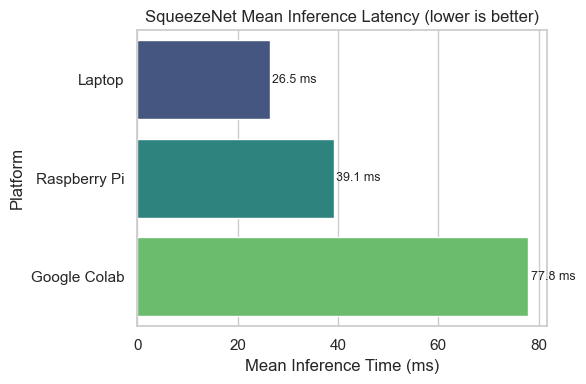

,Platform,Mean_ms,P95_ms
0,Laptop,26.507071,34.557162
1,Raspberry Pi,39.141993,39.806312
2,Google Colab,77.794803,155.052665


In [26]:
# 1. Latency comparison bar chart (robust)
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')

lat_rows=[]
for plat,data in platform_results.items():
    try:
        stats=data['core_performance']['statistics']
        mean_val=stats.get('mean_inference_time')
        p95_val=stats.get('p95_inference_time')
        if mean_val is None:
            print(f"Warning: missing mean_inference_time for {plat}")
            continue
        lat_rows.append({'Platform':plat,'Mean_ms':mean_val,'P95_ms':p95_val})
    except KeyError as e:
        print(f"Skipping {plat}, missing key: {e}")

lat_df=pd.DataFrame(lat_rows)
print('Raw latency rows:', lat_rows)
if lat_df.empty:
    print('No latency data available. Check that JSON files loaded contain core_performance.statistics.')
else:
    if 'Mean_ms' not in lat_df.columns:
        print('Mean_ms column missing after DataFrame creation; columns are:', lat_df.columns.tolist())
    else:
        lat_df=lat_df.sort_values('Mean_ms')
        plt.figure(figsize=(6,4))
        ax=sns.barplot(data=lat_df,x='Mean_ms',y='Platform',palette='viridis')
        for i,row in lat_df.iterrows():
            ax.text(row['Mean_ms']*1.01,i,f"{row['Mean_ms']:.1f} ms",va='center',fontsize=9)
        plt.title('SqueezeNet Mean Inference Latency (lower is better)')
        plt.xlabel('Mean Inference Time (ms)')
        plt.ylabel('Platform')
        plt.tight_layout()
        plt.show()
lat_df

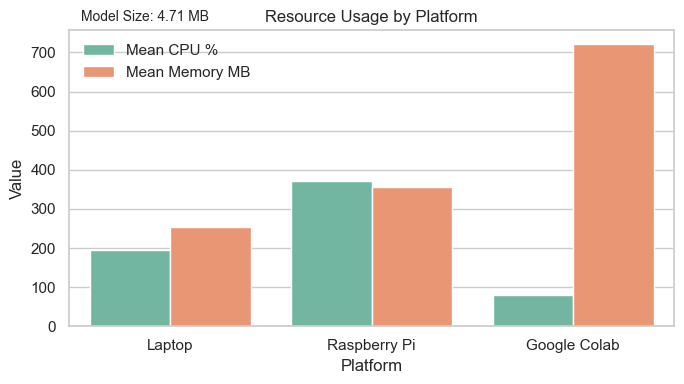

,Platform,Metric,Value
0,Laptop,Mean CPU %,195.330000
1,Laptop,Mean Memory MB,254.551094
2,Raspberry Pi,Mean CPU %,371.502000
3,Raspberry Pi,Mean Memory MB,355.350469
4,Google Colab,Mean CPU %,79.423000
5,Google Colab,Mean Memory MB,720.390625


In [27]:
# 2. Resource usage grouped bars (CPU, Memory) + model size annotation
res_rows=[]
for plat,data in platform_results.items():
    stats=data['core_performance']['statistics']
    res_rows.append({'Platform':plat,'Metric':'Mean CPU %','Value':stats['mean_cpu_usage']})
    res_rows.append({'Platform':plat,'Metric':'Mean Memory MB','Value':stats['mean_memory_usage']})
res_df=pd.DataFrame(res_rows)

plt.figure(figsize=(7,4))
ax=sns.barplot(data=res_df,x='Platform',y='Value',hue='Metric',palette='Set2')
plt.title('Resource Usage by Platform')
plt.ylabel('Value')
plt.xlabel('Platform')
plt.legend(frameon=False)
# Model size: assume same so show once; else could loop
model_size=next(iter(platform_results.values()))['model_info']['size_mb'] if platform_results else 0
plt.text(0.02,1.02,f"Model Size: {model_size:.2f} MB",transform=ax.transAxes,fontsize=10,ha='left',va='bottom')
plt.tight_layout(); plt.show()
res_df

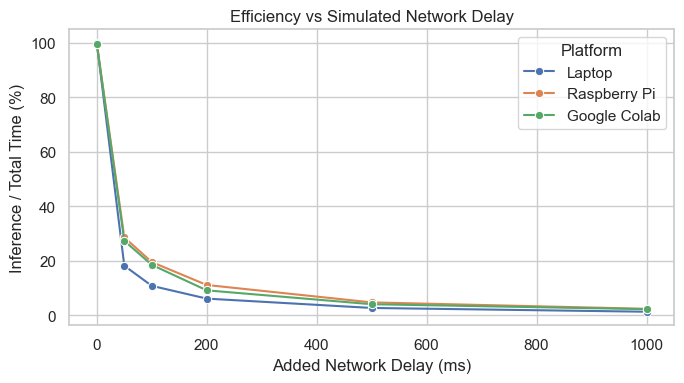

,Platform,Delay_ms,Efficiency_%
0,Laptop,0,99.968093
1,Laptop,50,18.200624
2,Laptop,100,10.813756
3,Laptop,200,6.129472
4,Laptop,500,2.697160


In [28]:
# 3. Network efficiency vs simulated delay (if latency_analysis present)
net_rows=[]
for plat,data in platform_results.items():
    lat_analysis=data.get('latency_analysis', {})
    for delay,vals in lat_analysis.items():
        net_rows.append({'Platform':plat,'Delay_ms':int(delay),'Efficiency_%':vals['efficiency_ratio']})
net_df=pd.DataFrame(net_rows)
if not net_df.empty:
    plt.figure(figsize=(7,4))
    sns.lineplot(data=net_df,x='Delay_ms',y='Efficiency_%',hue='Platform',marker='o')
    plt.title('Efficiency vs Simulated Network Delay')
    plt.ylabel('Inference / Total Time (%)')
    plt.xlabel('Added Network Delay (ms)')
    plt.tight_layout(); plt.show()
net_df.head()

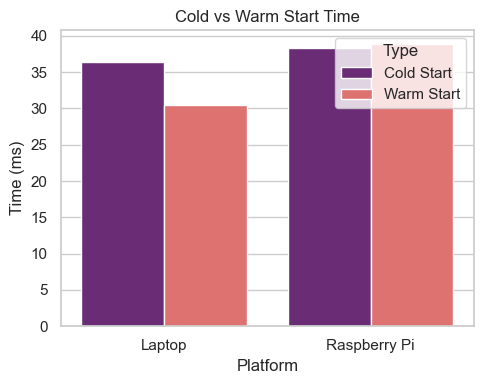

,Platform,Quantized,Status
0,Laptop,False,FP32
1,Raspberry Pi,False,FP32
2,Google Colab,False,FP32


In [29]:
# 4. Cold vs Warm start bar chart & 5. Quantization status
cold_rows=[]; quant_rows=[]
for plat,data in platform_results.items():
    cw=data.get('cold_warm_analysis',{}).get('statistics',{})
    if cw:
        cold_rows.append({'Platform':plat,'Type':'Cold Start','Time_ms':cw['cold_start_mean']})
        cold_rows.append({'Platform':plat,'Type':'Warm Start','Time_ms':cw['warm_start_mean']})
    quant_rows.append({'Platform':plat,'Quantized':data['model_info'].get('quantized',False)})

cold_df=pd.DataFrame(cold_rows); quant_df=pd.DataFrame(quant_rows)
if not cold_df.empty:
    plt.figure(figsize=(5,4))
    sns.barplot(data=cold_df,x='Platform',y='Time_ms',hue='Type',palette='magma')
    plt.title('Cold vs Warm Start Time')
    plt.ylabel('Time (ms)'); plt.xlabel('Platform')
    plt.tight_layout(); plt.show()

# Quantization summary display
quant_df['Status']=quant_df['Quantized'].map({True:'INT8 / Quantized', False:'FP32'})
quant_df